# Histograma — Aula 3

## Objetivo
Calcular e interpretar histogramas de intensidade, aplicar equalização, limiarização, realce de contraste e transformações não-lineares — sempre relacionando imagem de entrada e saída com seus histogramas.

## Especificações Técnicas
1. Histograma de imagem em escala de cinza
2. Histograma de cada canal de imagem colorida
3. Equalização de histograma (entrada e saída + histogramas)
4. Limiarização linear + histogramas
5. Colorida → cinza → aumento de contraste + histogramas
6. Lena em cinza + transformação não-linear + histogramas

## Base de Dados
- `../Aula 2/data/synthetic/` — gradiente, xadrez, constante (fixtures da Aula 2)
- `Lenna_(test_image).png` — imagem de referência
- Saídas em `data/output/` (gitignore)

## Material de Referência
- Aula anterior: `../Aula 2/notebook.ipynb`
- [OpenCV — histogramas](https://docs.opencv.org/4.x/d6/dc7/group__imgproc__hist.html)

## Parte 0: Setup e convenções

1. Setup completo (uma vez, na raiz do repo):

   ```powershell
   .\scripts\setup.ps1
   ```

2. **Em toda sessão**, ativar o ambiente virtual:

   ```powershell
   . .\scripts\activate.ps1
   .\scripts\verify-env.ps1
   ```

3. Kernel **PDI (.venv)** no Jupyter/Cursor.
4. Importar bibliotecas e definir caminhos com `pathlib`.
5. Reutilizar fixtures geradas na Aula 2.

**Conexão CS:** O histograma é um vetor de 256 contagens — compressão de H×W pixels em bins discretos (perde informação espacial).

**Tarefa:**
- O que significa reutilizar `data/synthetic/` da Aula 2 nesta aula?
- Por que manter saídas em `data/output/` separado das fixtures?

In [25]:
# Caminhos e I/O
import sys
from pathlib import Path


import cv2
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "Lenna_(test_image).png").exists():
    candidate = ROOT / "experiment" / "Aula 3"
    if (candidate / "Lenna_(test_image).png").exists():
        ROOT = candidate

AULA2_DIR = ROOT.parent / "Aula 2"
SYNTHETIC_DIR = AULA2_DIR / "data" / "synthetic"
OUTPUT_DIR = ROOT / "data" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LENA_PATH = ROOT / "Lenna_(test_image).png"
GRADIENT_PATH = SYNTHETIC_DIR / "gradient_gray.png"
CHECKER_PATH = SYNTHETIC_DIR / "checker_color.png"
CONSTANT_PATH = SYNTHETIC_DIR / "constant_150.png"

print(f"[INFO] ROOT: {ROOT}")
print(f"[INFO] Fixtures Aula 2: {SYNTHETIC_DIR}")
print(f"[OK] Diretorios prontos: output")

[INFO] ROOT: c:\dev\digital-image-processing\experiment\Aula 3
[INFO] Fixtures Aula 2: c:\dev\digital-image-processing\experiment\Aula 2\data\synthetic
[OK] Diretorios prontos: output


**Respostas:**

- **Reutilizar `data/synthetic/` da Aula 2:** Significa que estamos usando a mesma base de dados controlada (imagens de teste sintéticas como gradientes e xadrez) para analisar o efeito do histograma e de outras operações. Isso economiza espaço em disco, evita duplicação de dados e mantém a consistência dos experimentos e das fixtures de teste ao longo das aulas.

- **Separar `data/output/` das fixtures:** Para seguir as melhores práticas de engenharia de software e de ciência de dados: as fixtures (imagens de entrada em `data/synthetic/` ou `Lenna_(test_image).png`) são imutáveis e devem ser versionadas no Git. Já os artefatos de saída em `data/output/` são mutáveis, são gerados dinamicamente em tempo de execução e devem ser ignorados pelo controle de versão (através do `.gitignore`). Isso evita o inchaço do repositório Git com imagens redundantes.


## Parte 1: Experimento 1 — Histograma em escala de cinza

1. Ler `gradient_gray.png`
2. Calcular histograma com `cv2.calcHist`
3. Exibir imagem e histograma lado a lado

**Conexão CS:** Cada bin `h[i]` conta pixels com intensidade `i` — operação **reduce** sobre a matriz.

**Tarefa:**
- Qual a soma de todos os bins? O que ela representa?
- Onde o histograma do gradiente horizontal concentra mais contagens?

[INFO] shape=(256, 256), min=0, max=255


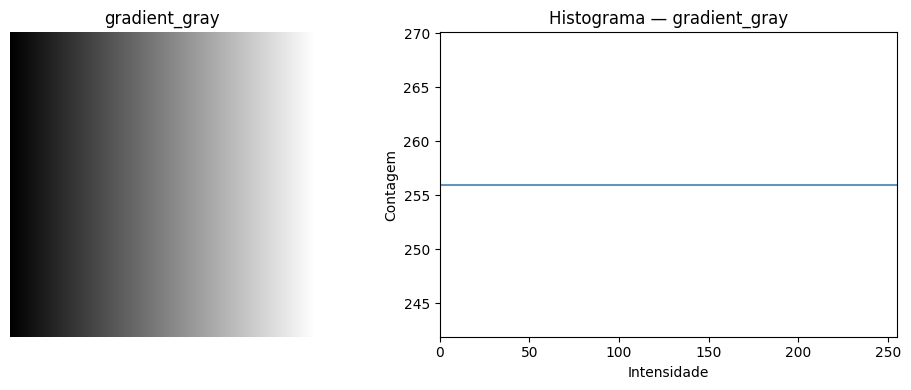

[INFO] Soma dos bins = 65536 (H*W=65536)


In [26]:
def gray_histogram(img: np.ndarray, bins: int = 256) -> np.ndarray:
    """
    Compute grayscale histogram as a 1D count vector.

    Parameters
    ----------
    img : numpy.ndarray
        Grayscale image (2D, uint8).
    bins : int
        Number of intensity bins.

    Returns
    -------
    numpy.ndarray
        Histogram counts with shape ``(bins,)``.
    """
    if img.ndim != 2:
        raise ValueError(f"Expected 2D grayscale, got shape {img.shape}")
    hist = cv2.calcHist([img], [0], None, [bins], [0, 256])
    return hist.flatten()


def show_gray_with_histogram(img: np.ndarray, title: str = "Imagem") -> None:
    """Display grayscale image and its histogram side by side."""
    hist = gray_histogram(img)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[0].set_title(title)
    axes[0].axis("off")
    axes[1].plot(np.arange(len(hist)), hist, color="steelblue", alpha=0.85, linewidth=1.5)
    axes[1].set_xlim(0, 255)
    axes[1].set_xlabel("Intensidade")
    axes[1].set_ylabel("Contagem")
    axes[1].set_title(f"Histograma — {title}")
    plt.tight_layout()
    plt.show()


img_grad = cv2.imread(str(GRADIENT_PATH), cv2.IMREAD_GRAYSCALE)
print(f"[INFO] shape={img_grad.shape}, min={img_grad.min()}, max={img_grad.max()}")

show_gray_with_histogram(img_grad, title="gradient_gray")
print(f"[INFO] Soma dos bins = {int(gray_histogram(img_grad).sum())} (H*W={img_grad.size})")

**Respostas:**

- **Soma de todos os bins:** A soma de todos os bins do histograma é igual a $N = H \times W$ (o produto da altura pela largura da imagem, que é o número total de pixels da imagem). Ela representa que cada pixel foi contado exatamente uma única vez na distribuição de frequência.

- **Concentração das contagens:** Como se trata de um gradiente horizontal linear e contínuo, a distribuição de intensidades é aproximadamente uniforme ao longo de toda a escala de tons de cinza presentes. No entanto, se houver limites de saturação (por exemplo, faixas totalmente pretas ou brancas nas bordas), haverá picos nas intensidades 0 e 255.


## Parte 2: Experimento 2 — Histograma por canal (colorida)

1. Ler `checker_color.png` (BGR no OpenCV)
2. Calcular histograma de cada canal
3. Exibir imagem (RGB) e três histogramas

**Tarefa:** Por que os histogramas de B, G e R diferem neste xadrez vermelho/azul?

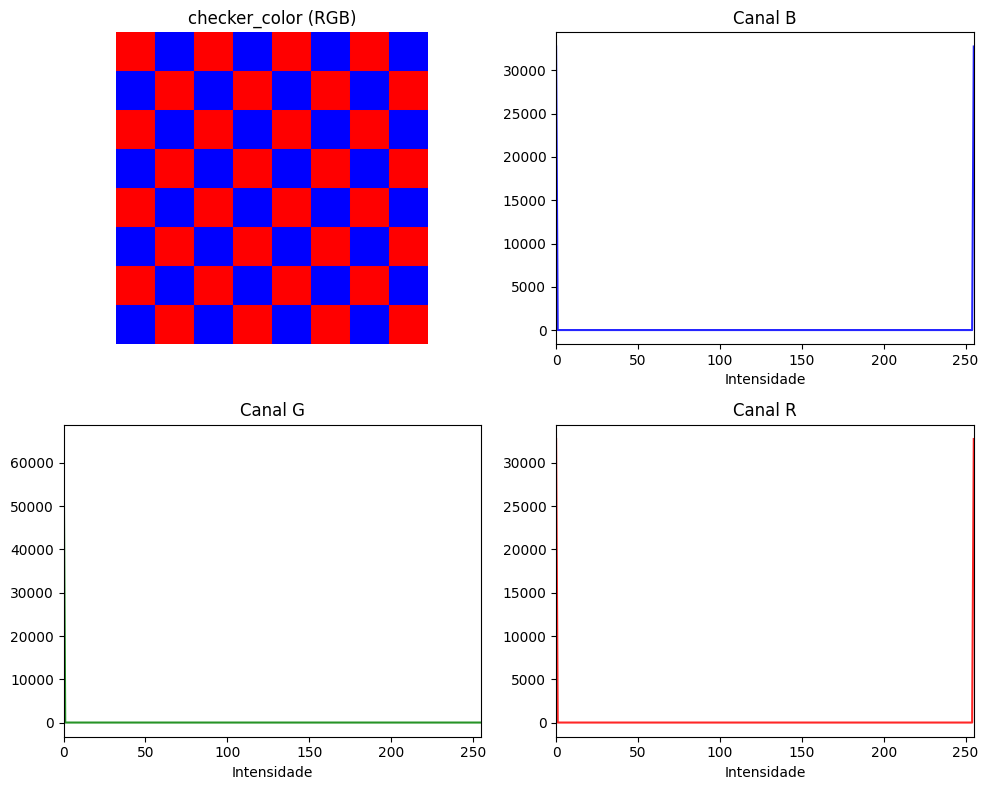

[INFO] Canal B: pico(s) em 0 e 255 (valor: 32768)
[INFO] Canal G: pico(s) em 0 (valor: 65536)
[INFO] Canal R: pico(s) em 0 e 255 (valor: 32768)


In [27]:
def channel_histograms_bgr(img_bgr: np.ndarray) -> dict[str, np.ndarray]:
    """Return per-channel histograms for a BGR image (keys B, G, R)."""
    names = ["B", "G", "R"]
    return {
        name: cv2.calcHist([img_bgr], [i], None, [256], [0, 256]).flatten()
        for i, name in enumerate(names)
    }


img_bgr = cv2.imread(str(CHECKER_PATH), cv2.IMREAD_COLOR)
hists = channel_histograms_bgr(img_bgr)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title("checker_color (RGB)")
axes[0, 0].axis("off")

colors = {"B": "blue", "G": "green", "R": "red"}
for idx, (name, hist) in enumerate(hists.items()):
    ax = axes.flat[idx + 1]
    ax.plot(np.arange(256), hist, color=colors[name], alpha=0.85, linewidth=1.5)
    ax.set_xlim(0, 255)
    ax.set_title(f"Canal {name}")
    ax.set_xlabel("Intensidade")

plt.tight_layout()
plt.show()

for name, hist in hists.items():
    max_val = hist.max()
    peaks = np.where(hist == max_val)[0]
    peaks_str = " e ".join(map(str, peaks))
    print(f"[INFO] Canal {name}: pico(s) em {peaks_str} (valor: {int(max_val)})")


**Respostas:**

- **Diferença nos histogramas de B, G e R:** Diferem porque a imagem é composta por blocos alternados de cores primárias fortes (principalmente azul puro e vermelho puro) com pouquíssimo ou nenhum verde. No canal **Azul (B)**, teremos alta concentração de pixels com alta intensidade nos blocos azuis (próximos de 255) e baixa intensidade nos blocos vermelhos (próximos de 0). No canal **Vermelho (R)**, ocorre o oposto: alta intensidade nos blocos vermelhos e baixa nos azuis. No canal **Verde (G)**, a grande maioria dos pixels se concentra em torno de 0, pois a cor verde não faz parte da composição majoritária deste xadrez vermelho/azul.


## Parte 3: Experimento 3 — Equalização de histograma

1. Ler Lena em escala de cinza
2. Aplicar `cv2.equalizeHist`
3. Mostrar imagens e histogramas (entrada vs saída)

**Conexão CS:** Equalização define uma função de transferência monotona T(i) a partir da CDF do histograma.

**Tarefa:** O histograma de saída fica perfeitamente uniforme? Por quê?

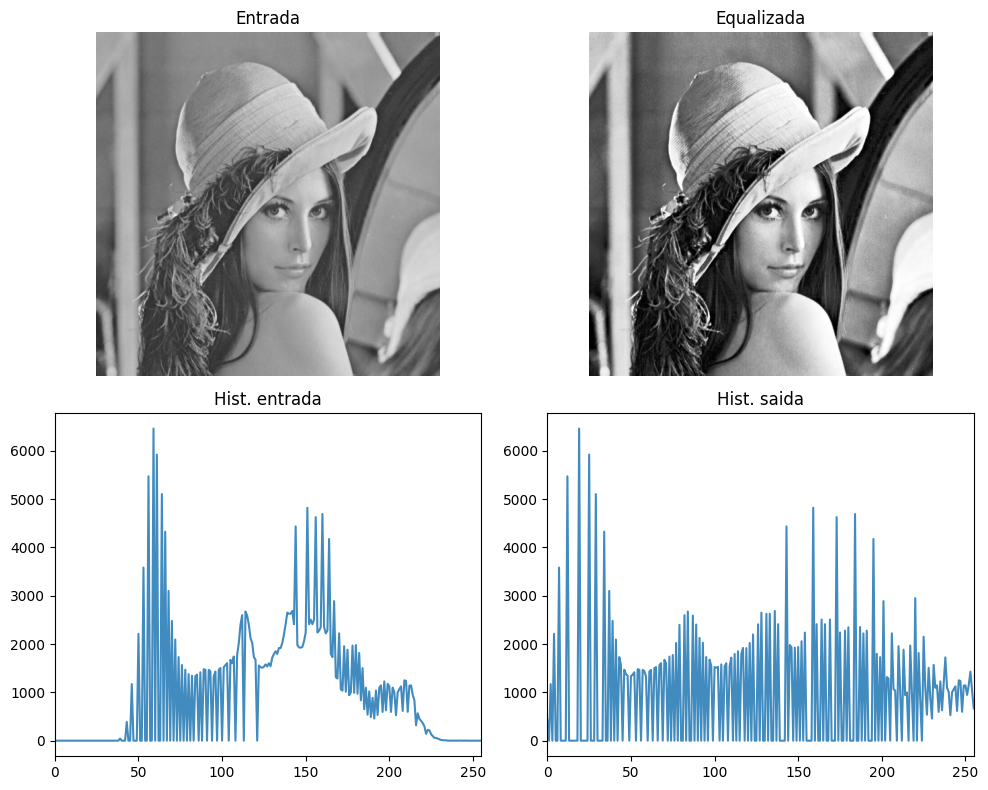

[OK] Gravado: c:\dev\digital-image-processing\experiment\Aula 3\data\output\lena_equalized.png


In [28]:
def equalize_gray(img: np.ndarray) -> np.ndarray:
    """Apply global histogram equalization."""
    return cv2.equalizeHist(img)


lena_gray = cv2.imread(str(LENA_PATH), cv2.IMREAD_GRAYSCALE)
lena_eq = equalize_gray(lena_gray)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].imshow(lena_gray, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Entrada")
axes[0, 0].axis("off")
axes[0, 1].imshow(lena_eq, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title("Equalizada")
axes[0, 1].axis("off")

for ax, arr, label in zip(axes[1], [lena_gray, lena_eq], ["entrada", "saida"]):
    h = gray_histogram(arr)
    ax.plot(np.arange(256), h, alpha=0.85, linewidth=1.5)
    ax.set_xlim(0, 255)
    ax.set_title(f"Hist. {label}")

plt.tight_layout()
plt.show()

cv2.imwrite(str(OUTPUT_DIR / "lena_equalized.png"), lena_eq)
print(f"[OK] Gravado: {OUTPUT_DIR / 'lena_equalized.png'}")

**Respostas:**

- **Histograma de saída uniforme:** Não, o histograma de saída não fica perfeitamente uniforme (plano). Em processamento digital de imagens, a imagem e os níveis de intensidade são **discretos** e quantizados. A função de mapeamento de equalização (baseada na CDF discreta) mapeia todos os pixels de um determinado nível de cinza de entrada para um único nível de cinza de saída. Como não é possível dividir pixels de mesma intensidade em níveis de cinza de saída diferentes, o histograma resultante exibe picos, vales e "lacunas" (gaps), embora sua distribuição acumulada (CDF) se aproxime de uma linha reta linear.


## Parte 4: Experimento 4 — Limiarização (thresholding)

1. Ler imagem em escala de cinza (Lena)
2. Aplicar limiarização linear com `cv2.threshold`
3. Mostrar imagens e histogramas (entrada vs saída)

**Tarefa:** Quantos bins do histograma de saída têm contagem > 0? Por quê?

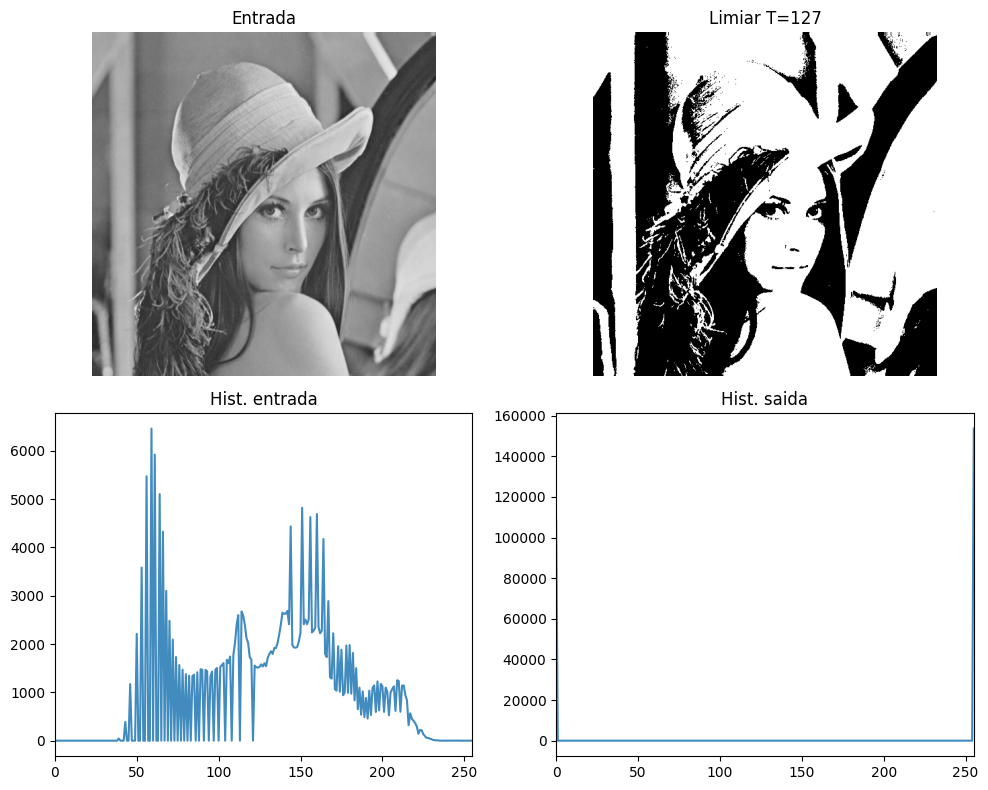

[INFO] Bins > 0 na saida: 2


In [29]:
THRESH_VALUE = 127


def apply_binary_threshold(img: np.ndarray, thresh: int) -> np.ndarray:
    """Apply fixed binary threshold (THRESH_BINARY)."""
    _, binary = cv2.threshold(img, thresh, 255, cv2.THRESH_BINARY)
    return binary


src = cv2.imread(str(LENA_PATH), cv2.IMREAD_GRAYSCALE)
binary = apply_binary_threshold(src, THRESH_VALUE)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].imshow(src, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Entrada")
axes[0, 0].axis("off")
axes[0, 1].imshow(binary, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title(f"Limiar T={THRESH_VALUE}")
axes[0, 1].axis("off")

for ax, arr, label in zip(axes[1], [src, binary], ["entrada", "saida"]):
    h = gray_histogram(arr)
    ax.plot(np.arange(256), h, alpha=0.85, linewidth=1.5)
    ax.set_xlim(0, 255)
    ax.set_title(f"Hist. {label}")

plt.tight_layout()
plt.show()

hist_out = gray_histogram(binary)
print(f"[INFO] Bins > 0 na saida: {int(np.count_nonzero(hist_out))}")

**Respostas:**

- **Bins > 0 na saída:** Apenas **2 bins** têm contagem maior que 0. Isso ocorre porque a operação aplicada foi a limiarização binária (`cv2.THRESH_BINARY`), que mapeia todos os pixels da imagem para apenas dois valores de intensidade possíveis: `0` (para pixels com intensidade original $\le 127$) e `255` (para pixels com intensidade original $> 127$). Portanto, todos os bins entre 1 e 254 ficam vazios (contagem igual a zero).


## Parte 5: Experimento 5 — Colorida → cinza → contraste

1. Ler imagem colorida (Lena)
2. Converter para escala de cinza
3. Aumentar contraste (CLAHE)
4. Mostrar imagens e histogramas

**Tarefa:** Compare o histograma após CLAHE com o da equalização global (Parte 3).

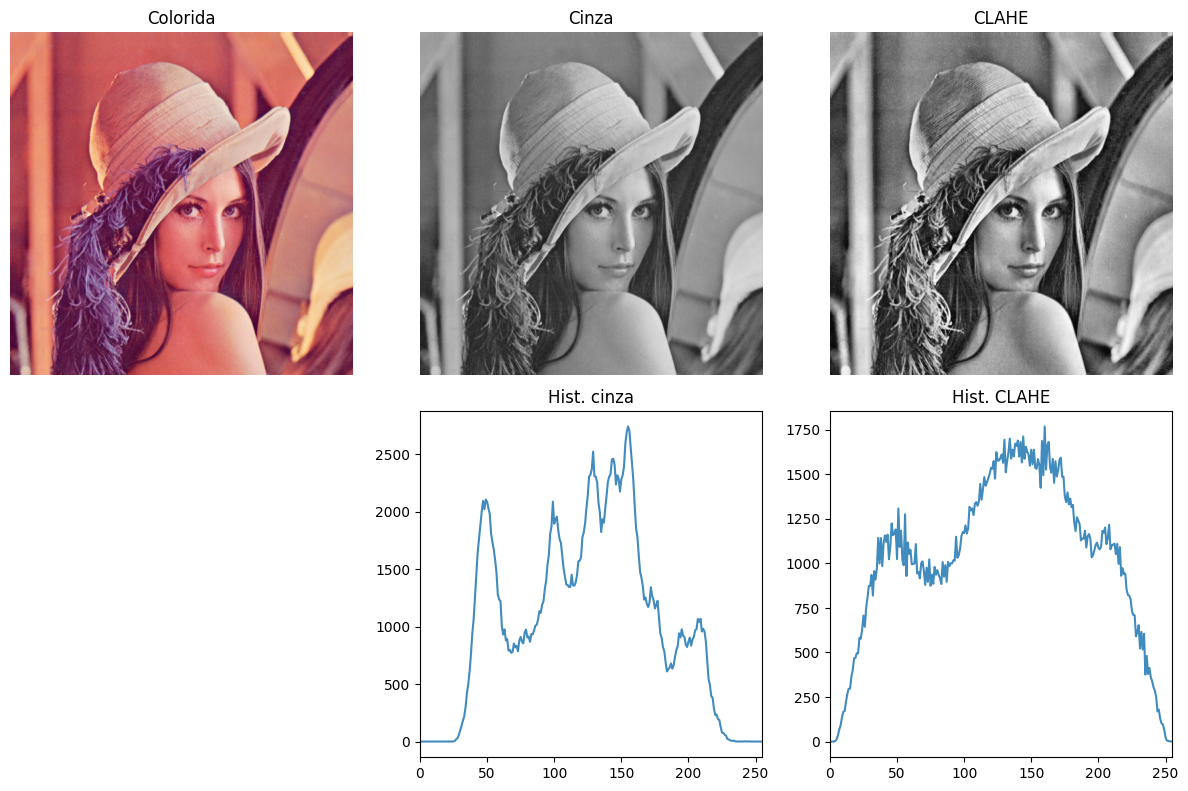

[OK] Gravado: c:\dev\digital-image-processing\experiment\Aula 3\data\output\lena_clahe.png


In [30]:
def enhance_contrast_clahe(img_gray: np.ndarray, clip_limit: float = 2.0) -> np.ndarray:
    """Apply CLAHE contrast enhancement."""
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(8, 8))
    return clahe.apply(img_gray)


img_color = cv2.imread(str(LENA_PATH), cv2.IMREAD_COLOR)
gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
enhanced = enhance_contrast_clahe(gray)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes[0, 0].imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title("Colorida")
axes[0, 0].axis("off")
axes[0, 1].imshow(gray, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title("Cinza")
axes[0, 1].axis("off")
axes[0, 2].imshow(enhanced, cmap="gray", vmin=0, vmax=255)
axes[0, 2].set_title("CLAHE")
axes[0, 2].axis("off")

for col, (arr, label) in enumerate([(gray, "cinza"), (enhanced, "CLAHE")], start=1):
    h = gray_histogram(arr)
    axes[1, col].plot(np.arange(256), h, alpha=0.85, linewidth=1.5)
    axes[1, col].set_xlim(0, 255)
    axes[1, col].set_title(f"Hist. {label}")
axes[1, 0].axis("off")

plt.tight_layout()
plt.show()

cv2.imwrite(str(OUTPUT_DIR / "lena_clahe.png"), enhanced)
print(f"[OK] Gravado: {OUTPUT_DIR / 'lena_clahe.png'}")

**Respostas:**

- **Comparação CLAHE vs Equalização Global:** A equalização global aplica uma única transformação monotônica obtida a partir da CDF global da imagem, o que pode causar superexposição e amplificação de ruído. O CLAHE (Adaptativo) divide a imagem em sub-regiões (tiles), calcula a equalização local para cada uma e limita a inclinação da curva de transferência (`clipLimit`) para reduzir a amplificação de ruído em áreas uniformes, interpolando os blocos de forma bilinear. O histograma resultante de CLAHE preserva melhor a forma geral e a estrutura bimodal/multimodal do histograma original, distribuindo e suavizando as contagens de forma mais suave, sem as grandes lacunas de espaçamento vistas na equalização global.


## Parte 6: Experimento 6 — Lena e transformação não-linear

1. Ler Lena em escala de cinza
2. Aplicar correção gamma (transformação não-linear)
3. Mostrar imagens, curva de transferência e histogramas

**Tarefa:** Execute com `GAMMA = 0.5` e `GAMMA = 2.0`. Como o histograma se desloca em cada caso?

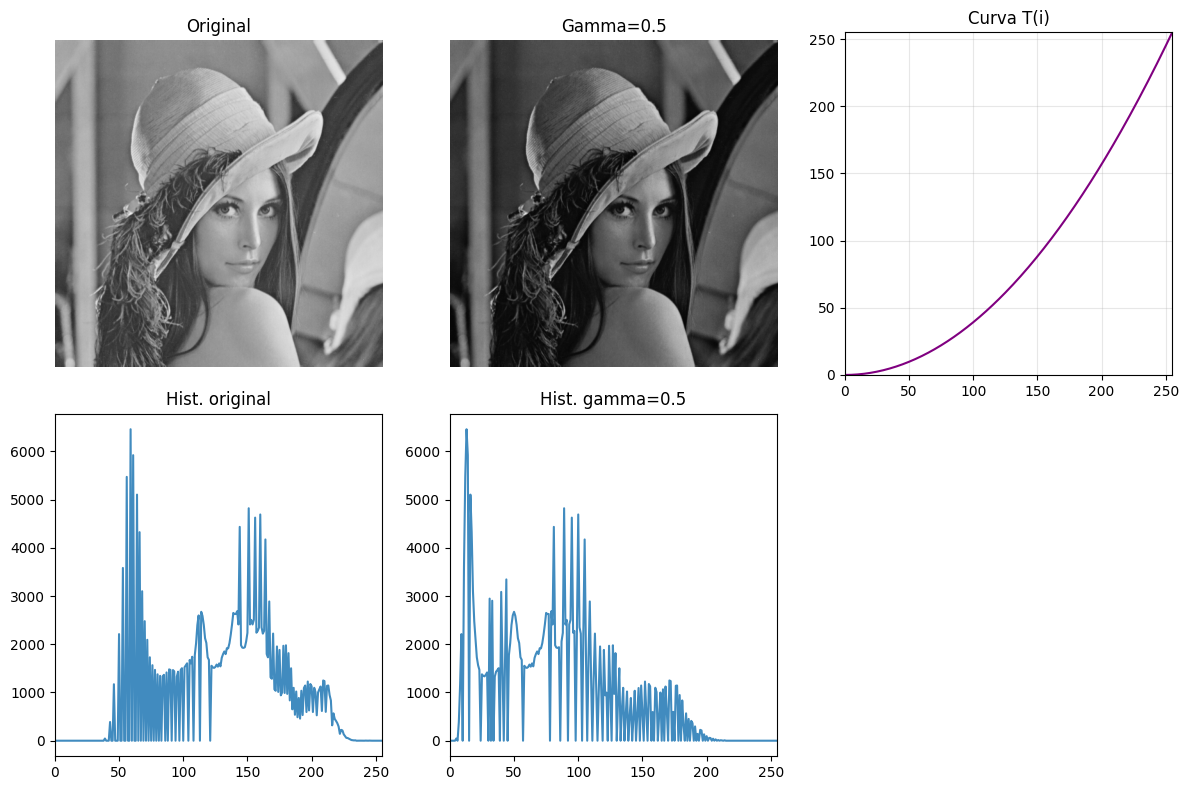

[OK] Gravado: c:\dev\digital-image-processing\experiment\Aula 3\data\output\lena_gamma_0.5.png


In [31]:
GAMMA = 0.5


def gamma_correct(img: np.ndarray, gamma: float) -> np.ndarray:
    """Apply gamma correction via lookup table."""
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)], dtype=np.uint8)
    return cv2.LUT(img, table)


lena = cv2.imread(str(LENA_PATH), cv2.IMREAD_GRAYSCALE)
lena_gamma = gamma_correct(lena, GAMMA)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes[0, 0].imshow(lena, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")
axes[0, 1].imshow(lena_gamma, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title(f"Gamma={GAMMA}")
axes[0, 1].axis("off")

x = np.linspace(0, 255, 256)
y = 255 * (x / 255) ** (1.0 / GAMMA)
axes[0, 2].plot(x, y, color="purple")
axes[0, 2].set_xlim(0, 255)
axes[0, 2].set_ylim(0, 255)
axes[0, 2].set_title("Curva T(i)")
axes[0, 2].grid(True, alpha=0.3)

for ax, arr, label in zip(axes[1, :2], [lena, lena_gamma], ["original", f"gamma={GAMMA}"]):
    h = gray_histogram(arr)
    ax.plot(np.arange(256), h, alpha=0.85, linewidth=1.5)
    ax.set_xlim(0, 255)
    ax.set_title(f"Hist. {label}")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

cv2.imwrite(str(OUTPUT_DIR / f"lena_gamma_{GAMMA}.png"), lena_gamma)
print(f"[OK] Gravado: {OUTPUT_DIR / f'lena_gamma_{GAMMA}.png'}")

**Respostas:**

- **Deslocamento do histograma com Gamma:**
  - **Para GAMMA = 0.5:** A potência aplicada é `2.0` (inv_gamma = 2.0). A curva de transferência $T(i)$ fica abaixo da identidade, fazendo com que tons de cinza intermediários sejam mapeados para valores mais baixos (a imagem escurece). O histograma **desloca-se para a esquerda** (em direção ao preto/zero).
  - **Para GAMMA = 2.0:** A potência aplicada é `0.5` (inv_gamma = 0.5). A curva de transferência $T(i)$ fica acima da identidade, mapeando os pixels para valores de intensidade maiores (a imagem clareia). O histograma **desloca-se para a direita** (em direção ao branco/255).


## Parte 7: Síntese

| Experimento | Operação | Efeito típico no histograma |
|-------------|----------|----------------------------|
| 1 | Contagem | Forma da distribuição de intensidades |
| 2 | Por canal | Três distribuições (BGR) |
| 3 | Equalização global | Espalha bins; aproxima uniforme |
| 4 | Limiarização | Apenas bins 0 e 255 |
| 5 | CLAHE | Realce local; histograma mais preenchido |
| 6 | Gamma | Desloca massa conforme curva T(i) |

**Ligação com Aula 2:** Somar +100 desloca o histograma à direita (até saturar em 255).

**Checklist — aprendi de verdade?**
1. Soma dos bins = ?
2. Diferença equalização global vs CLAHE?
3. Por que threshold deixa só dois bins?
4. O que gamma < 1 faz às sombras?

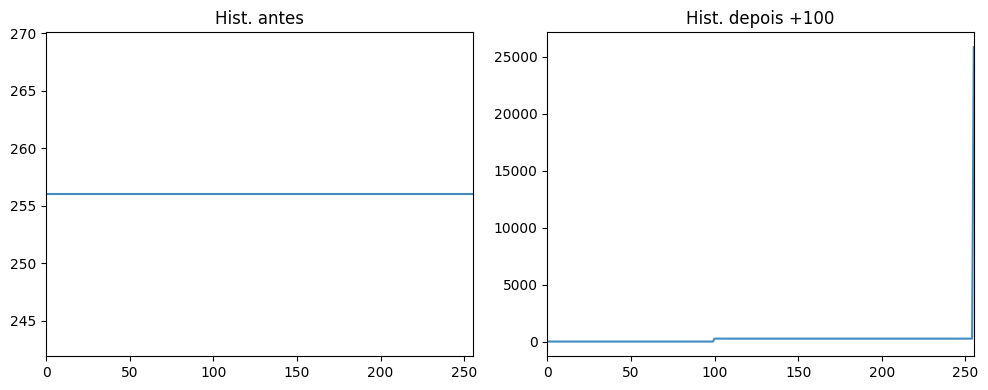

[INFO] Pico deslocou ~100 bins (saturacao em 255 nas colunas altas).


In [32]:
# Ponte Aula 2 — deslocamento do histograma após +100
from pathlib import Path as _P  # noqa: já importado

grad = cv2.imread(str(GRADIENT_PATH), cv2.IMREAD_GRAYSCALE)
bright = cv2.add(grad, 100)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, arr, label in zip(axes, [grad, bright], ["antes", "depois +100"]):
    h = gray_histogram(arr)
    ax.plot(np.arange(256), h, alpha=0.85, linewidth=1.5)
    ax.set_xlim(0, 255)
    ax.set_title(f"Hist. {label}")
plt.tight_layout()
plt.show()
print("[INFO] Pico deslocou ~100 bins (saturacao em 255 nas colunas altas).")

**Respostas — Checklist final:**

1. **Soma dos bins = ?** É igual ao número total de pixels da imagem ($H \times W$).
2. **Diferença equalização global vs CLAHE?** A equalização global aplica uma única transformação baseada no histograma de toda a imagem (podendo causar superexposição). O CLAHE (Adaptativo) realiza a equalização localmente em blocos de tamanho reduzido (tiles) e impõe um limite à amplificação de contraste para evitar realçar o ruído de fundo, suavizando a transição entre blocos através de interpolação bilinear.
3. **Por que threshold deixa só dois bins?** Porque binariza a imagem, mapeando todos os pixels para os valores extremos da escala (`0` para fundo e `255` para objetos acima do limiar).
4. **O que gamma < 1 faz às sombras?** Na implementação deste notebook, onde o expoente aplicado é $1/\gamma$ (então $\gamma < 1$ resulta em expoente $> 1$), as sombras são comprimidas e tornam-se ainda mais escuras, diminuindo o brilho global da imagem e aumentando o contraste nas áreas claras.
